<a href="https://colab.research.google.com/github/kaonashithank1022/data-analysis-basic-kadai/blob/main/text/14%E7%AB%A0_%E6%99%82%E7%B3%BB%E5%88%97%E5%88%86%E6%9E%90%E3%81%AE%E6%89%8B%E6%B3%95%E3%82%92%E5%AD%A6%E3%81%BC%E3%81%86_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   ds      144 non-null    object
 1   y       144 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.4+ KB


INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,1949-01-01,107.406531,55.825432,114.509711,107.406531,107.406531,-21.387397,-21.387397,-21.387397,-21.387397,-21.387397,-21.387397,0.0,0.0,0.0,86.019134
1,1949-02-01,109.550753,49.792747,107.674645,109.550753,109.550753,-30.055287,-30.055287,-30.055287,-30.055287,-30.055287,-30.055287,0.0,0.0,0.0,79.495466
2,1949-03-01,111.487469,85.075114,138.145906,111.487469,111.487469,-0.461745,-0.461745,-0.461745,-0.461745,-0.461745,-0.461745,0.0,0.0,0.0,111.025724
3,1949-04-01,113.631691,82.110217,137.996918,113.631691,113.631691,-4.912527,-4.912527,-4.912527,-4.912527,-4.912527,-4.912527,0.0,0.0,0.0,108.719164
4,1949-05-01,115.706744,83.545008,139.993808,115.706744,115.706744,-3.611280,-3.611280,-3.611280,-3.611280,-3.611280,-3.611280,0.0,0.0,0.0,112.095464
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,1963-08-01,583.129514,619.791465,678.220922,580.263835,586.007460,67.604372,67.604372,67.604372,67.604372,67.604372,67.604372,0.0,0.0,0.0,650.733886
176,1963-09-01,586.261162,574.886316,631.896830,583.226558,589.300041,17.222399,17.222399,17.222399,17.222399,17.222399,17.222399,0.0,0.0,0.0,603.483562
177,1963-10-01,589.291790,539.367835,597.118898,586.116394,592.488146,-22.032210,-22.032210,-22.032210,-22.032210,-22.032210,-22.032210,0.0,0.0,0.0,567.259580
178,1963-11-01,592.423438,506.362878,564.446389,589.090960,595.786840,-56.983693,-56.983693,-56.983693,-56.983693,-56.983693,-56.983693,0.0,0.0,0.0,535.439745


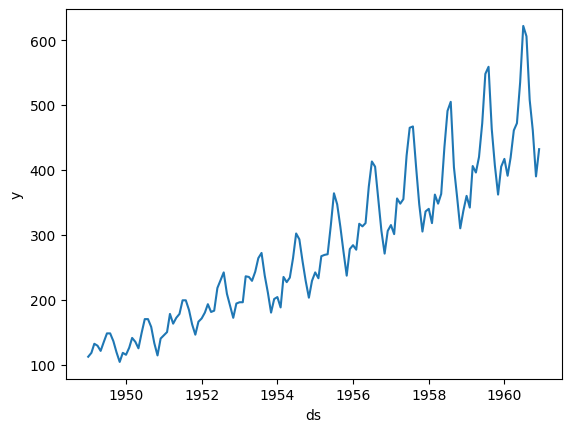

In [1]:

#必要な道具（ライブラリ）を取り出す
import pandas as pd
import seaborn as sns
from prophet import Prophet

#GitHub上のURLから、Prophetの公式サンプルデータセット（1949年〜1960年の月別航空旅客数）を読み込み
#12年分（144か月分、期間1949/1/1～1960/12/1）の旅客数データで、ds列に日付、y列に旅客数が配置されているデータ
df = pd.read_csv('https://raw.githubusercontent.com/facebook/prophet/main/examples/example_air_passengers.csv')
df


#df['ds']（文字列形式の日付）を pd.to_datetime() で日付型データに変換
time = pd.to_datetime(df['ds'])
#seabornのlineplot関数で、折れ線グラフを表示
#横軸は時間（time）、縦軸は旅客数（y)
sns.lineplot(x=time, y=df['y'])

#欠損がないことを確認
df.info()

#Prophetクラスをインポートし、インスタンス化
#Prophet（設計図）を用意
from prophet import Prophet
#Prophet() で実体（model）を作る
model = Prophet()

#準備したデータ df を渡して、過去のデータのトレンドや季節性をモデルに学習させる
#model（実体）が fit（命令）を使って df（データ）を読み込み、自分の中に学習結果を保存す
model.fit(df)

#make_future_dataframe(): 過去のデータの日付に加え、これから予測したい未来の日付を含んだデータフレームを自動生成
#periodsパラメータ：予測期間として追加する行数を指定　→36か月
#freqパラメータ：追加する日時データの間隔を指定　→Month Start（毎月1日）
#出来上がった表データに future というラベルを貼って保管
future = model.make_future_dataframe(periods=36, freq='MS')
future

#データフレーム(future)を引数に指定して、predictメソッドで予測を行う

forecast = model.predict(future)
forecast



In [2]:
#日付、旅客数の予測値、不確実性区間の下限と上限を抽出
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']]


,ds,yhat,yhat_lower,yhat_upper
0,1949-01-01,86.019134,55.825432,114.509711
1,1949-02-01,79.495466,49.792747,107.674645
2,1949-03-01,111.025724,85.075114,138.145906
3,1949-04-01,108.719164,82.110217,137.996918
4,1949-05-01,112.095464,83.545008,139.993808
...,...,...,...,...
175,1963-08-01,650.733886,619.791465,678.220922
176,1963-09-01,603.483562,574.886316,631.896830
177,1963-10-01,567.259580,539.367835,597.118898
178,1963-11-01,535.439745,506.362878,564.446389


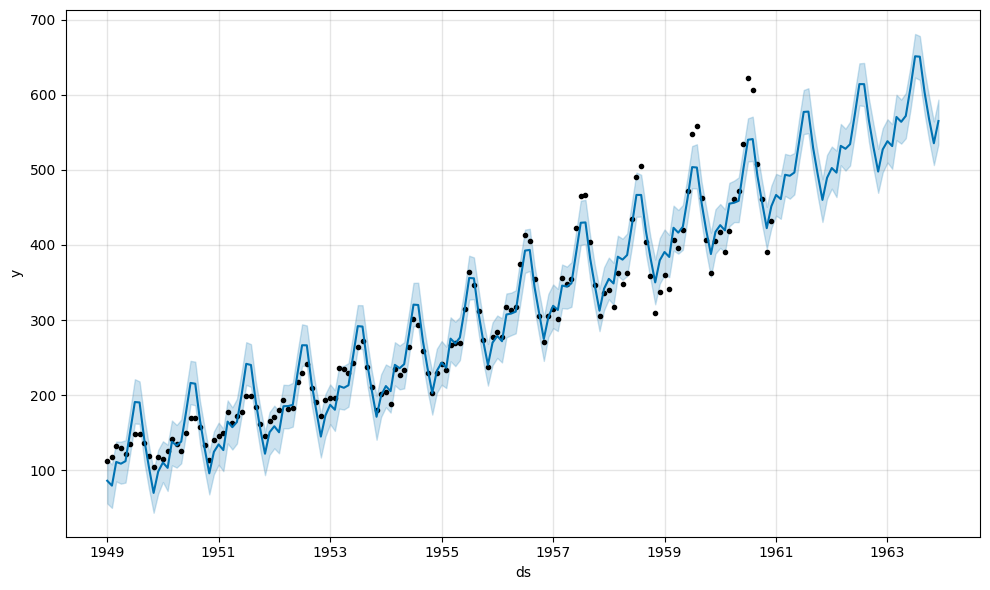

In [3]:
#抽出した値をグラフ上に可視化
#黒点が旅客数の実際の値、青ラインが予測モデルによる旅客数の予測値、水色のエリアが予測値の不確実性区間
fig_forecast = model.plot(forecast)


In [4]:
#予測の評価
#テストパターンを作成するcross_validation関数をインポート
from prophet.diagnostics import cross_validation


#cutoffs	いつまでのデータを学習データとするかという期限の日付
#pd.to_datetime を使って「Pythonの日付データ型」に変換しておくことで、エラーを防ぐ安全対策
cutoffs = pd.to_datetime(['1954-12-01', '1955-12-01', '1956-12-01', '1957-12-01'])

#horizon	cutoffs翌日以降のテスト期間
#完成したテスト結果の表に df_cv というラベルを貼り付けて保存
df_cv = cross_validation(model, horizon = '1096 days', cutoffs=cutoffs)


#df_cvに3年（36か月）×4パターン = 144行のデータが格納されていることを確認
df_cv

  0%|          | 0/4 [00:00<?, ?it/s]

,ds,yhat,yhat_lower,yhat_upper,y,cutoff
0,1955-01-01,237.821919,225.474634,249.272974,242,1954-12-01
1,1955-02-01,241.792031,230.572128,253.686158,233,1954-12-01
2,1955-03-01,267.141175,256.662880,277.629460,267,1954-12-01
3,1955-04-01,257.744411,245.907600,268.934932,269,1954-12-01
4,1955-05-01,261.961869,249.776949,272.933730,270,1954-12-01
...,...,...,...,...,...,...
139,1960-08-01,548.443189,529.934747,568.049368,606,1957-12-01
140,1960-09-01,511.578097,492.343255,532.119952,508,1957-12-01
141,1960-10-01,480.747857,459.278940,500.650092,461,1957-12-01
142,1960-11-01,455.417886,435.697889,475.799890,390,1957-12-01


In [5]:
#評価指標を算出するperformance_metrics関数をインポート
from prophet.diagnostics import performance_metrics


#引数にdf_cvを指定して、performance_metrics関数を実行
df_p = performance_metrics(df_cv)
df_p.head()

#horizon列を月単位で表示
df_p = performance_metrics(df_cv, monthly=True)
df_p.head()

,horizon,mse,rmse,mae,mape,mdape,smape,coverage
0,4,662.882429,25.746503,18.530661,0.057799,0.039788,0.055068,0.571429
1,5,577.740585,24.036235,16.903356,0.051203,0.030947,0.049111,0.642857
2,6,676.262157,26.005041,19.591839,0.056243,0.036983,0.056366,0.535714
3,7,1338.376512,36.583829,29.852158,0.078469,0.068215,0.081789,0.357143
4,8,1849.987757,43.011484,38.904609,0.097044,0.107400,0.102882,0.178571


<Axes: xlabel='horizon', ylabel='mse'>

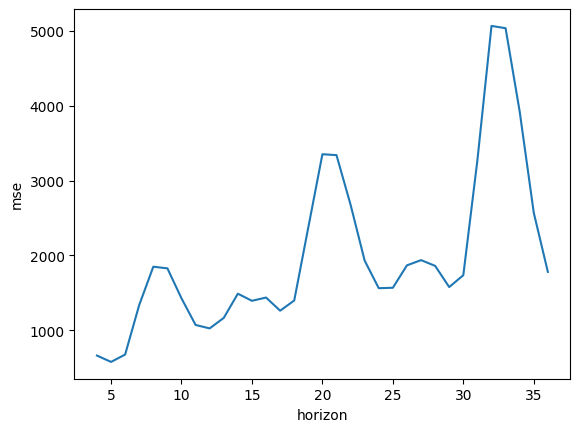

In [9]:
#実際の値と予測値の平均二乗誤差であるmseの推移を可視化
#seabornのlineplot関数を活
sns.lineplot(x='horizon', y='mse', data=df_p)

#時間の経過に伴って、徐々に誤差が増加している

<Axes: xlabel='horizon', ylabel='coverage'>

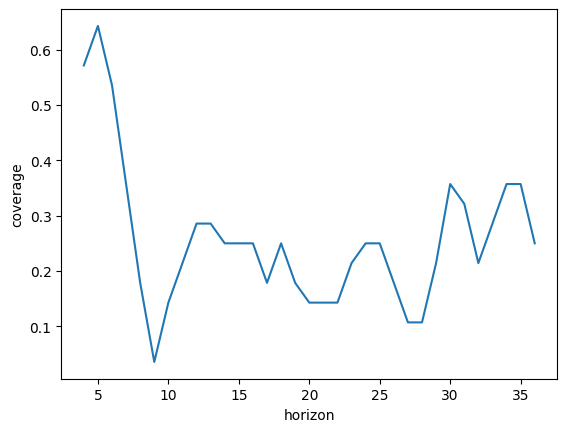

In [10]:
#不確実性区間に予測値が含まれている割合であるcoverageの推移を可視化
sns.lineplot(x='horizon', y='coverage', data=df_p)

#不確実性区間に実際の値が含まれる割合は、10-30%程度を推移している

タイムマシンテスト（df_cv）で得た結果からズレを数値（df_p）にし、グラフ化することで『このモデルは◯ヶ月先までは精度が高いが、◯年先になるとズレが大きくなる』という実力を評価した」 という作業を行っている

